# Single-slice DLPFC

This tutorial identifies spatial domains in DLPFC section 151672. It builds edge- and triangle-induced topology, trains SpaDiff, and compares the resulting domains with cortical-layer annotations.

Set `DATA_ROOT` to the sample directory. The optional `truth.txt` file is used only for evaluation.

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.spatial import spatial_reconstruction
from SpaDiff.utils import mclust_R, set_seed
from SpaDiff.topology import build_simplicial_operators, to_torch_operators

## Configuration

In [4]:
SEED = 42
SAMPLE_ID = "151672"
N_CLUSTERS = 5
N_NEIGHBORS = 10
training_epochs = 500


MAX_ORDER = 2
SIMPLEX_ORDERS = (
    (0,) if MAX_ORDER == 0
    else tuple(range(1, MAX_ORDER + 1))
)

DSM_WEIGHTING = "variance"
DSM_LOSS_WEIGHT = 1.0
BATCH_LOSS_WEIGHT = 0.0
BATCH_POSTERIOR_SCALE = 0.0
PRIOR_KL_LOSS_WEIGHT = 1.0


DATA_ROOT = Path("E:/gxy_2/final/0_data/case1")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)

DATA_ROOT = E:\gxy_2\final\0_data\case1
device = cuda:0


## Data loading and preprocessing

In [5]:
sample_dir = DATA_ROOT / SAMPLE_ID
adata = sc.read_visium(sample_dir)
adata.var_names_make_unique()

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts", n_top_genes=3000, subset=True)
truth = pd.read_csv(sample_dir / "truth.txt", sep="\t", header=None, index_col=0)
truth.columns = ["Truth"]
adata.obs["Truth"] = truth.reindex(adata.obs_names)["Truth"]
adata

AnnData object with n_obs × n_vars = 4015 × 3000
    obs: 'in_tissue', 'array_row', 'array_col', 'Truth'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'
    layers: 'counts'

## Spatial topology

In [6]:
adata, adjacency = spatial_reconstruction(adata, alpha=2.0, n_neighbors=N_NEIGHBORS)

operators = to_torch_operators(build_simplicial_operators(adjacency, max_order=MAX_ORDER), device=device)

sc.tl.pca(adata, n_comps=50)
features = torch.as_tensor(np.asarray(adata.obsm["X_pca"]), dtype=torch.float32, device=device)

Simplicial complex statistics:
  order 0 (vertices): 4,015
  order 1 (edges): 19,043
  order 2 (triangles): 23,982


In [8]:
print("features:", tuple(features.shape))

features: (4015, 50)


## SpaDiff training

In [9]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    num_batches=1,
    num_modalities=1,
    num_scales=1000,
    topology_hidden_dim=128,
    topology_dim=64,
    propagation_steps=5,
    propagation_alpha=0.4,
    hidden_dim=128,
    dropout=0.1,
    topology_projection_dropout=0.0,
    learnable_propagation=False,
    topology_residual=True,
    topology_output_normalization="feature",
    simplex_orders=SIMPLEX_ORDERS,
    dsm_weighting=DSM_WEIGHTING,
    dsm_weight=DSM_LOSS_WEIGHT,
    batch_alignment_weight=BATCH_LOSS_WEIGHT,
    batch_posterior_weight=BATCH_POSTERIOR_SCALE,
    prior_kl_weight=PRIOR_KL_LOSS_WEIGHT,
)
model = sd.SpaDiff(config).to(device)
adata = model.fit_transform(
    adata,
    features,
    operators,
    batch_key=None,
    epochs=training_epochs,
    progress=True,
    ode_steps=200,
)

Training SpaDiff: 100%|██████████| 500/500 [00:11<00:00, 45.13epoch/s]


## Spatial domains

The example clusters `adata.obsm["spadiff"]` with mclust. Louvain or Leiden can be used when R is unavailable.

In [10]:
labels = mclust_R(adata, num_cluster=N_CLUSTERS, used_obsm="spadiff",pca_num=20, random_seed=SEED)
adata.obs["mclust"] = pd.Categorical(labels.astype(str))

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 5.4.10
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


ARI = 0.787
NMI = 0.735


[<AxesSubplot: title={'center': 'SpaDiff paper-aligned | ARI=0.787'}, xlabel='spatial1', ylabel='spatial2'>]

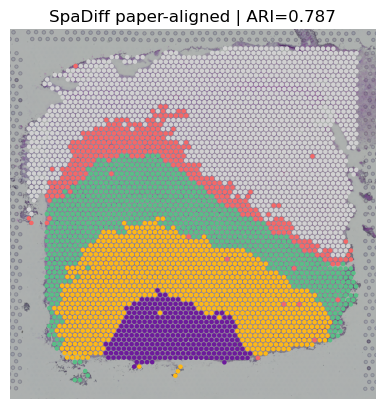

In [12]:
valid = adata.obs[["mclust", "Truth"]].dropna()
ari = round(adjusted_rand_score(valid["Truth"], valid["mclust"]),3)
nmi = normalized_mutual_info_score(valid["Truth"], valid["mclust"])

print(f"ARI = {ari:.3f}")
print(f"NMI = {nmi:.3f}")

palette = ["#6D1A9C", "#D1D1D1", "#F56867", "#59BE86", "#FEB915", "#C798EE", "#7495D3"]
sc.pl.spatial(
    adata, img_key="hires", color="mclust", palette=palette,
    title=f"SpaDiff paper-aligned | ARI={ari:.3f}", legend_loc=None,
    frameon=False, spot_size=120,
    show=False,
)
# plt.savefig("../result/spadiff_"+SAMPLE_ID+"_"+str(ari)+".pdf", bbox_inches='tight')

In [ ]:
# output_file = "../result/spadiff_" + SAMPLE_ID + "_" + str(ari) + ".h5ad"

# adata.write_h5ad(output_file, compression="gzip")